# Importing packages

In [2]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

In [3]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

In [4]:
adata = ad.read_h5ad(results_dir / "adata.h5ad")

In [5]:
extra_patient_info = pd.read_excel(metadata_dir / 'extra_patients_info.xlsx', sheet_name='Detailed info')
#get the survival time in months and event
extra_patient_info["survival_time_months"] = extra_patient_info["Survival after NMC diagnosis"].str.split(" month").str[0].astype(float)
adata.obs = adata.obs.merge(extra_patient_info, how='left', left_on='patient_ID', right_on='patient_ID')
adata.obs["patient_exp"] = adata.obs["patient_ID"].astype(str) + "_" + adata.obs["rois"].astype(str)


In [10]:
adata.obs

,cell_id,cell_type,level,parent_cell,type_no,Cell 3D Volume,Cell Bbox Bottom,Cell Bbox Left,Cell Bbox Right,Cell Bbox Top,...,Lymph node involvement/ metastases,Therapy (local),Therapy (systemic),Survival after diagnosis of malignacy,Survival after NMC diagnosis,"treatment before MACSima sample withdrawal? If yes, which treatment?",site of biopsy/resection for MACSima sample,MACSima sample type,survival_time_months,patient_exp
0,1,NFC,1,0,21,1224,33,18,0,68,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
1,2,Tumor_cells,1,0,14,830,31,111,0,144,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
2,3,Tumor_cells,1,0,14,894,38,141,0,172,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
3,4,Tumor_cells,1,0,14,386,23,1469,0,1487,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
4,5,Tumor_cells,1,0,14,2331,39,1485,0,1567,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492868,17816,Endothelial_cells,1,0,15,1622,12657,9559,12626,9628,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13
492869,17817,Endothelial_cells,1,0,15,9293,12657,10139,12528,10287,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13
492870,17818,Tumor_cells,1,0,14,1201,12657,4209,12629,4283,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13
492871,17819,NFC,1,0,21,5569,12657,3572,12574,3680,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13


In [17]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                         phenotype='cell_type', label='2D_distance', imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run145_ROI3
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run145_ROI10
Processing Image: Run145_ROI11
Processing Image: Run141_ROI15
Processing Image: Run145_ROI1
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run145_ROI9
Processing Image: Run141_ROI14
Processing Image: Run145_ROI14
Processing Image: Run145_ROI13


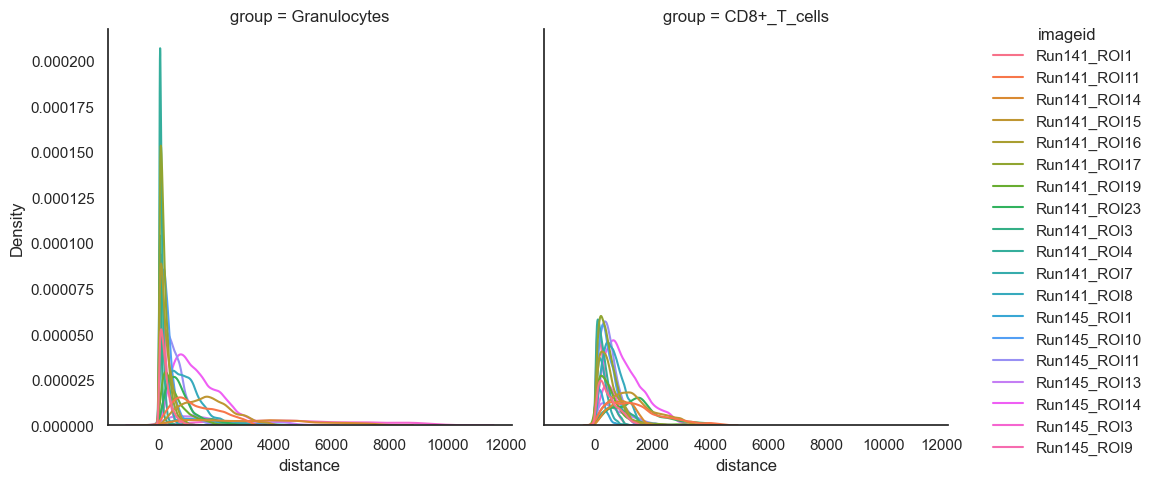

In [13]:
sm.pl.spatial_distance(adata, spatial_distance="2D_distance", phenotype="cell_type", imageid="exp_name", distance_from="Tumor_cells", method="distribution", distance_to=["Granulocytes", "CD8+_T_cells"], log=False)

In [1]:
import napari

ModuleNotFoundError: No module named 'napari'

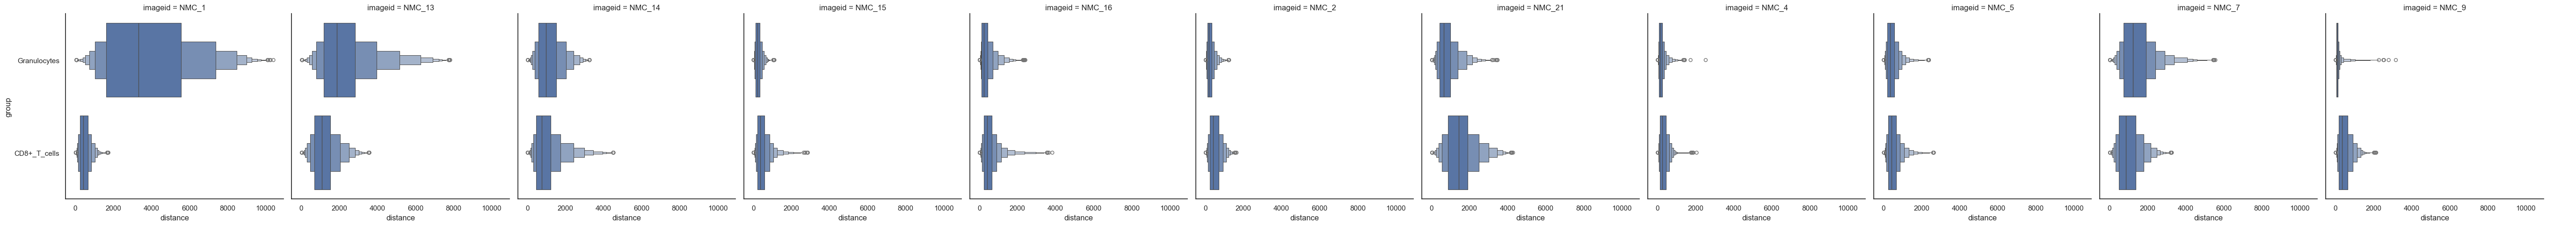

In [27]:
sm.pl.spatial_distance(adata, spatial_distance="2D_distance", phenotype="cell_type", imageid="patient_ID", distance_from="Tumor_cells", method="numeric", distance_to=["Granulocytes", "CD8+_T_cells"], log=False)

In [23]:
adata.obs

,cell_id,cell_type,level,parent_cell,type_no,Cell 3D Volume,Cell Bbox Bottom,Cell Bbox Left,Cell Bbox Right,Cell Bbox Top,...,Lymph node involvement/ metastases,Therapy (local),Therapy (systemic),Survival after diagnosis of malignacy,Survival after NMC diagnosis,"treatment before MACSima sample withdrawal? If yes, which treatment?",site of biopsy/resection for MACSima sample,MACSima sample type,survival_time_months,patient_exp
0,1,NFC,1,0,21,1224,33,18,0,68,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
1,2,Tumor_cells,1,0,14,830,31,111,0,144,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
2,3,Tumor_cells,1,0,14,894,38,141,0,172,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
3,4,Tumor_cells,1,0,14,386,23,1469,0,1487,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
4,5,Tumor_cells,1,0,14,2331,39,1485,0,1567,...,yes,R1 resection + R0 resection,"01.08.2018: Paclitaxel, 5-FU",19 months (80 weeks),13 months (59 weeks),-,retroportal lymph node (mainly tumor),r0,13.0,NMC_14_11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492868,17816,Endothelial_cells,1,0,15,1622,12657,9559,12626,9628,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13
492869,17817,Endothelial_cells,1,0,15,9293,12657,10139,12528,10287,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13
492870,17818,Tumor_cells,1,0,14,1201,12657,4209,12629,4283,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13
492871,17819,NFC,1,0,21,5569,12657,3572,12574,3680,...,yes,RTx,VAI/PAI\nCarboplatin/ Etoposid/ Paclitaxel \nB...,10 months (43 weeks),9 months (40 weeks),-,cervical lymph node,b1,9.0,NMC_7_13


In [26]:
distance_df = pd.DataFrame(adata.uns['2D_distance'])
distance_df["cell_type"] = adata.obs["cell_type"].values
distance_df["patient_ID"] = adata.obs["patient_ID"].values
distance_df["patient_exp"] = adata.obs["patient_exp"].values
#pivot longer 
distance_df = distance_df.melt(id_vars=["cell_type", "patient_ID", "patient_exp"], var_name="distance_to", value_name="distance")
#remove the tumor cells and NFC from cell type and distances to 
distance_df = distance_df[~distance_df["cell_type"].isin(["Tumor_cells", "NFC"])]
distance_df = distance_df[distance_df["distance_to"].isin(["Tumor_cells"])]
distance_df
#write distance_df to csv
distance_df.to_csv("/Users/jawadalaaedeen/Desktop/distance_df.csv", index=False)

In [ ]:
distance_df = pd.DataFrame(adata.uns['2D_distance'])
distance_df.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "outcome_group").loc[:,["exp_name", "patient_ID", "outcome_group"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_ID"].values
#filter out the tumor cells

In [18]:
#make a dataframe with adata.uns['2D_distance'] and adata.obs["cell_type"]
#select only Tumor_cells column
distance_df = distance_df[["Tumor_cells"]]
distance_df["cell_type"] = adata.obs["cell_type"].values
distance_df["patient_ID"] = adata.obs["patient_ID"].values
distance_df["patient_exp"] = adata.obs["patient_exp"].values
distance_df["tissue"] = adata.obs["site of biopsy/resection for MACSima sample"].values
distance_df["survival_time_months"] = adata.obs["survival_time_months"].values
distance_df


,Tumor_cells,cell_type,patient_ID,patient_exp,tissue,survival_time_months
0,40.051016,NFC,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
1,27.988594,Tumor_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
2,27.988594,Tumor_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
3,43.215335,Tumor_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
4,34.520335,Tumor_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
...,...,...,...,...,...,...
492868,571.120446,Endothelial_cells,NMC_7,NMC_7_13,cervical lymph node,9.0
492869,1018.650846,Endothelial_cells,NMC_7,NMC_7_13,cervical lymph node,9.0
492870,61.580706,Tumor_cells,NMC_7,NMC_7_13,cervical lymph node,9.0
492871,67.178922,NFC,NMC_7,NMC_7_13,cervical lymph node,9.0


In [42]:
immune_distance_df

,Tumor_cells,cell_type,patient_ID,patient_exp,tissue,survival_time_months
148,668.764989,CD8+_T_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
240,71.695597,CD8+_T_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
948,782.312604,Granulocytes,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
1163,252.920305,CD8+_T_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
1351,94.967162,CD8+_T_cells,NMC_14,NMC_14_11,retroportal lymph node (mainly tumor),13.0
...,...,...,...,...,...,...
492125,77.570699,CD8+_T_cells,NMC_7,NMC_7_13,cervical lymph node,9.0
492228,1031.361427,Granulocytes,NMC_7,NMC_7_13,cervical lymph node,9.0
492229,1089.172517,Granulocytes,NMC_7,NMC_7_13,cervical lymph node,9.0
492446,2028.631646,CD8+_T_cells,NMC_7,NMC_7_13,cervical lymph node,9.0


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_4500/273275877.py:4: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.




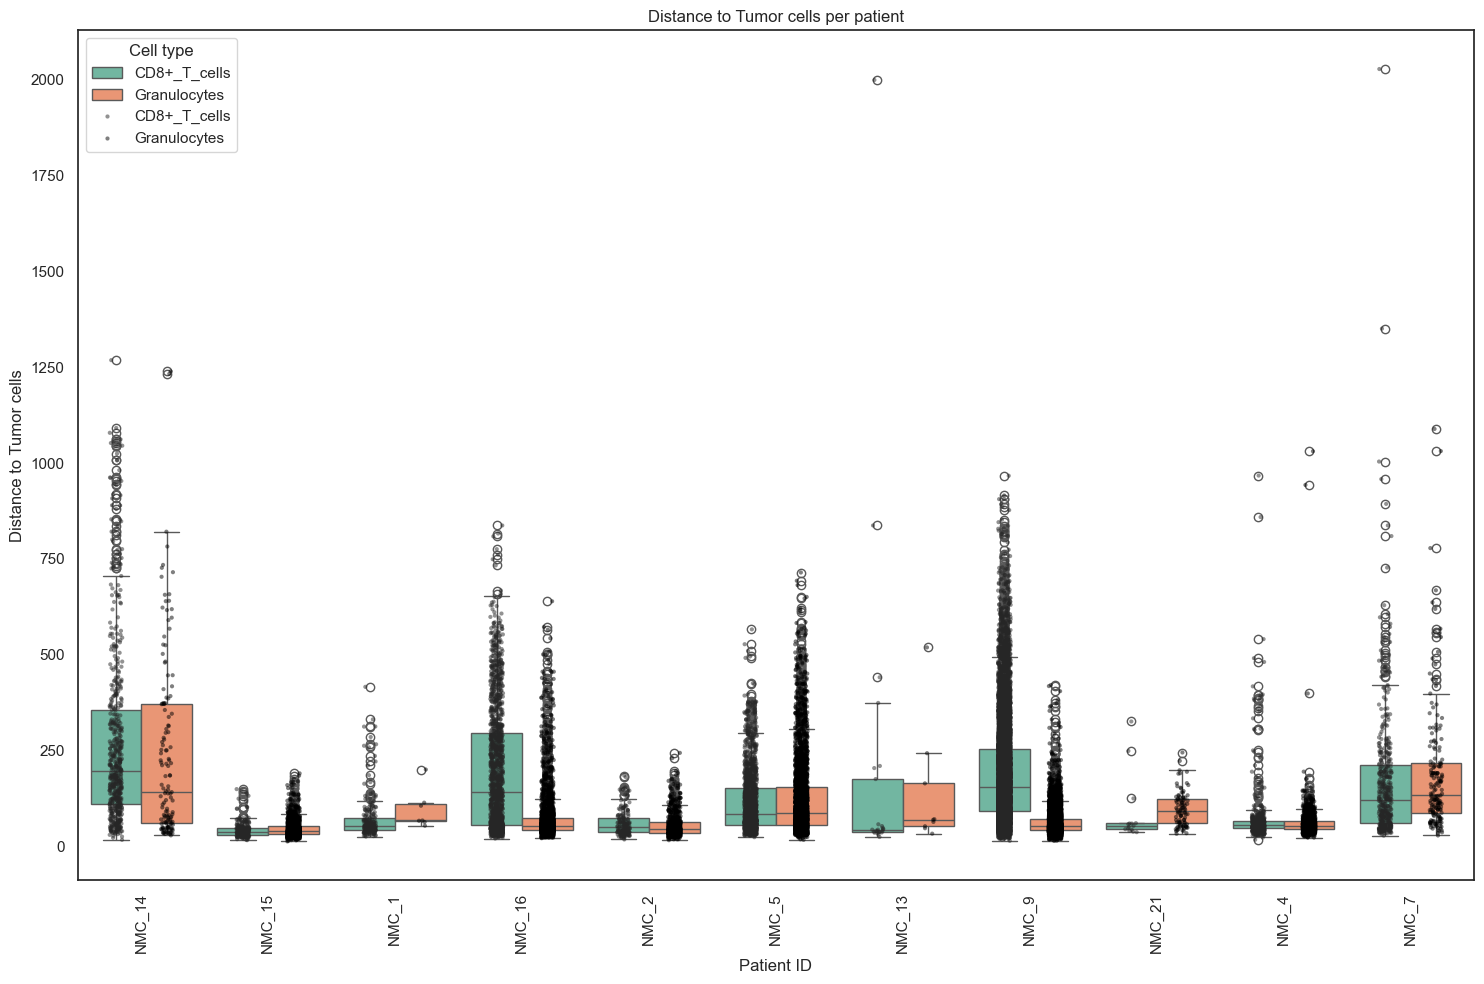

In [ ]:
#Build a boxplot showcasing the distance tumor cells per patient with cell_type as hue
plt.figure(figsize=(15, 10))
sns.boxplot(data=immune_distance_df, x="patient_ID", y="Tumor_cells", hue="cell_type", palette="Set2")
plt.xticks(rotation=90)
plt.xlabel("Patient ID")
plt.ylabel("Distance to Tumor cells")
plt.title("Distance to Tumor cells per patient")
plt.legend(title="Cell type")
plt.tight_layout()

## How interactions are similar across all sampless

## Spatial Interaction

In [28]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_type",
                         method='delaunay',
                         permutation=300,
                         imageid='exp_name',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['Run141_ROI11']
Categories (1, object): ['Run141_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI16']
Categories (1, object): ['Run141_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI7']
Categories (1, object): ['Run141_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI3']
Categories (1, object): ['Run145_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run1

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI15']
Categories (1, object): ['Run141_ROI15']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI1']
Categories (1, object): ['Run145_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI4']
Categories (1, object): ['Run141_ROI4']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI23']
Categories (1, object): ['Run141_ROI23']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI3']
Categories (1, object): ['Run141_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI9']
Categories (1, object): ['Run145_ROI9']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI14']
Categories (1, object): ['Run141_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permut

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run145_ROI13']
Categories (1, object): ['Run145_ROI13']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results


AnnData object with n_obs × n_vars = 492873 × 65
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [49]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "patient_ID").loc[:,["exp_name", "patient_ID", "patient_exp"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_exp"].values
#filter out the tumor cells
heatmap_data = heatmap_data.filter(like = "Tumor_cells-", axis=0)
#remove index with Tumor_cells-Tumor-cells
heatmap_data = heatmap_data.drop(index = "Tumor_cells-Tumor_cells")
heatmap_data = heatmap_data.drop(index = "Tumor_cells-Epithelial_cells")
heatmap_data = heatmap_data.drop(index = "Tumor_cells-NFC")
heatmap_data
#write heatmap_data to csv
heatmap_data.to_csv("/Users/jawadalaaedeen/Desktop/heatmap_data.csv")


In [45]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "outcome_group").loc[:,["exp_name", "patient_ID", "outcome_group"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_ID"].values
#filter out the tumor cells
heatmap_data = heatmap_data.filter(like = "Tumor_cells-", axis=0)
#remove index with Tumor_cells-Tumor-cells
heatmap_data = heatmap_data.drop(index = "Tumor_cells-Tumor_cells")
heatmap_data = heatmap_data.drop(index = "Tumor_cells-Epithelial_cells")


In [75]:
adata_lung = adata[adata.obs["site of biopsy/resection for MACSima sample"] == "lung"]
heatmap_data = adata_lung.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata_lung.obs.sort_values(by = "outcome_group").loc[:,["exp_name", "patient_ID", "outcome_group"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_ID"].values
#Extract both indexes Tumor_cells-CD8+_T_cells and Tumor_cells-Granulocytes=
heatmap_data = heatmap_data[heatmap_data.index.isin(["Tumor_cells-Granulocytes", "Tumor_cells-CD8+_T_cells"])]
heatmap_data
#filter out the tumor cells
#heatmap_data = heatmap_data.filter(like = "Tumor_cells-CD", axis=0)
#remove index with Tumor_cells-Tumor-cells
#heatmap_data = heatmap_data.drop(index = "Tumor_cells-Tumor_cells")
#heatmap_data = heatmap_data.drop(index = "Tumor_cells-Epithelial_cells")

,NMC_6,NMC_6,NMC_15,NMC_9,NMC_15,NMC_9,NMC_8,NMC_2
Tumor_cells-CD8+_T_cells,16.492735,7.533213,7.291538,13.916727,14.261169,19.201683,27.458588,20.651636
Tumor_cells-Granulocytes,22.352472,13.054513,22.561140,43.607667,43.866374,34.104894,39.025089,41.777907


In [50]:
boxplot_data = heatmap_data.T
boxplot_data.insert(0, "patient_ID", boxplot_data.index)
#pivot longer the data
boxplot_data = pd.melt(boxplot_data, id_vars="patient_ID", var_name="interaction", value_name="zscore")
boxplot_data

,patient_ID,interaction,zscore
0,NMC_1_3,Tumor_cells-Actin+_cells,31.180948
1,NMC_1_1,Tumor_cells-Actin+_cells,10.097511
2,NMC_13_14,Tumor_cells-Actin+_cells,0.587377
3,NMC_13_15,Tumor_cells-Actin+_cells,28.361572
4,NMC_14_8,Tumor_cells-Actin+_cells,18.986185
...,...,...,...
299,NMC_5_10,Tumor_cells-Treg_T_cells,17.610637
300,NMC_7_14,Tumor_cells-Treg_T_cells,22.635371
301,NMC_7_13,Tumor_cells-Treg_T_cells,10.270953
302,NMC_9_3,Tumor_cells-Treg_T_cells,14.776240


In [51]:
boxplot_data_select = boxplot_data[boxplot_data["interaction"].isin(["Tumor_cells-Granulocytes", "Tumor_cells-CD8+_T_cells"])]
boxplot_data_select

,patient_ID,interaction,zscore
57,NMC_1_3,Tumor_cells-CD8+_T_cells,7.375820
58,NMC_1_1,Tumor_cells-CD8+_T_cells,7.405124
59,NMC_13_14,Tumor_cells-CD8+_T_cells,7.384497
60,NMC_13_15,Tumor_cells-CD8+_T_cells,-0.344779
61,NMC_14_8,Tumor_cells-CD8+_T_cells,8.273152
62,NMC_14_11,Tumor_cells-CD8+_T_cells,13.599797
63,NMC_15_7,Tumor_cells-CD8+_T_cells,7.862570
64,NMC_15_16,Tumor_cells-CD8+_T_cells,15.142527
65,NMC_16_17,Tumor_cells-CD8+_T_cells,12.638981
66,NMC_16_19,Tumor_cells-CD8+_T_cells,32.876865


In [53]:
#save boxplot select as csv
boxplot_data_select.to_csv("/Users/jawadalaaedeen/Desktop/boxplot_data_select.csv", index=False)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/2379068901.py:10: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.25'` for the same effect.


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/2379068901.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




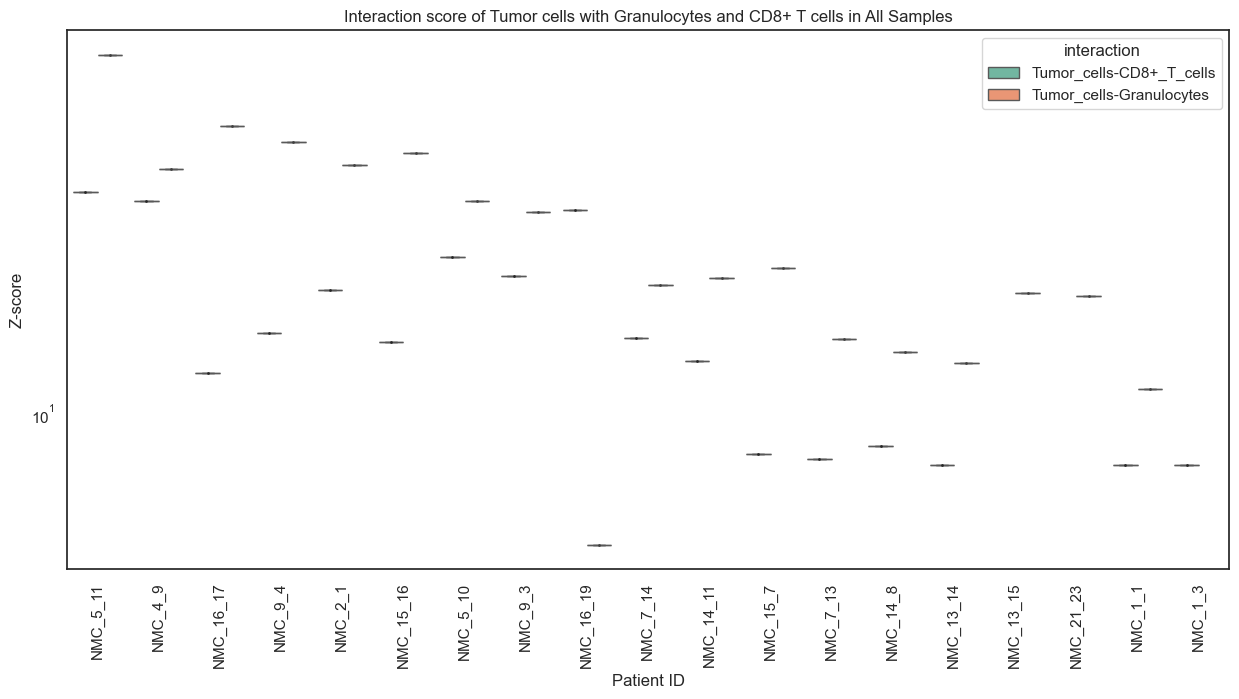

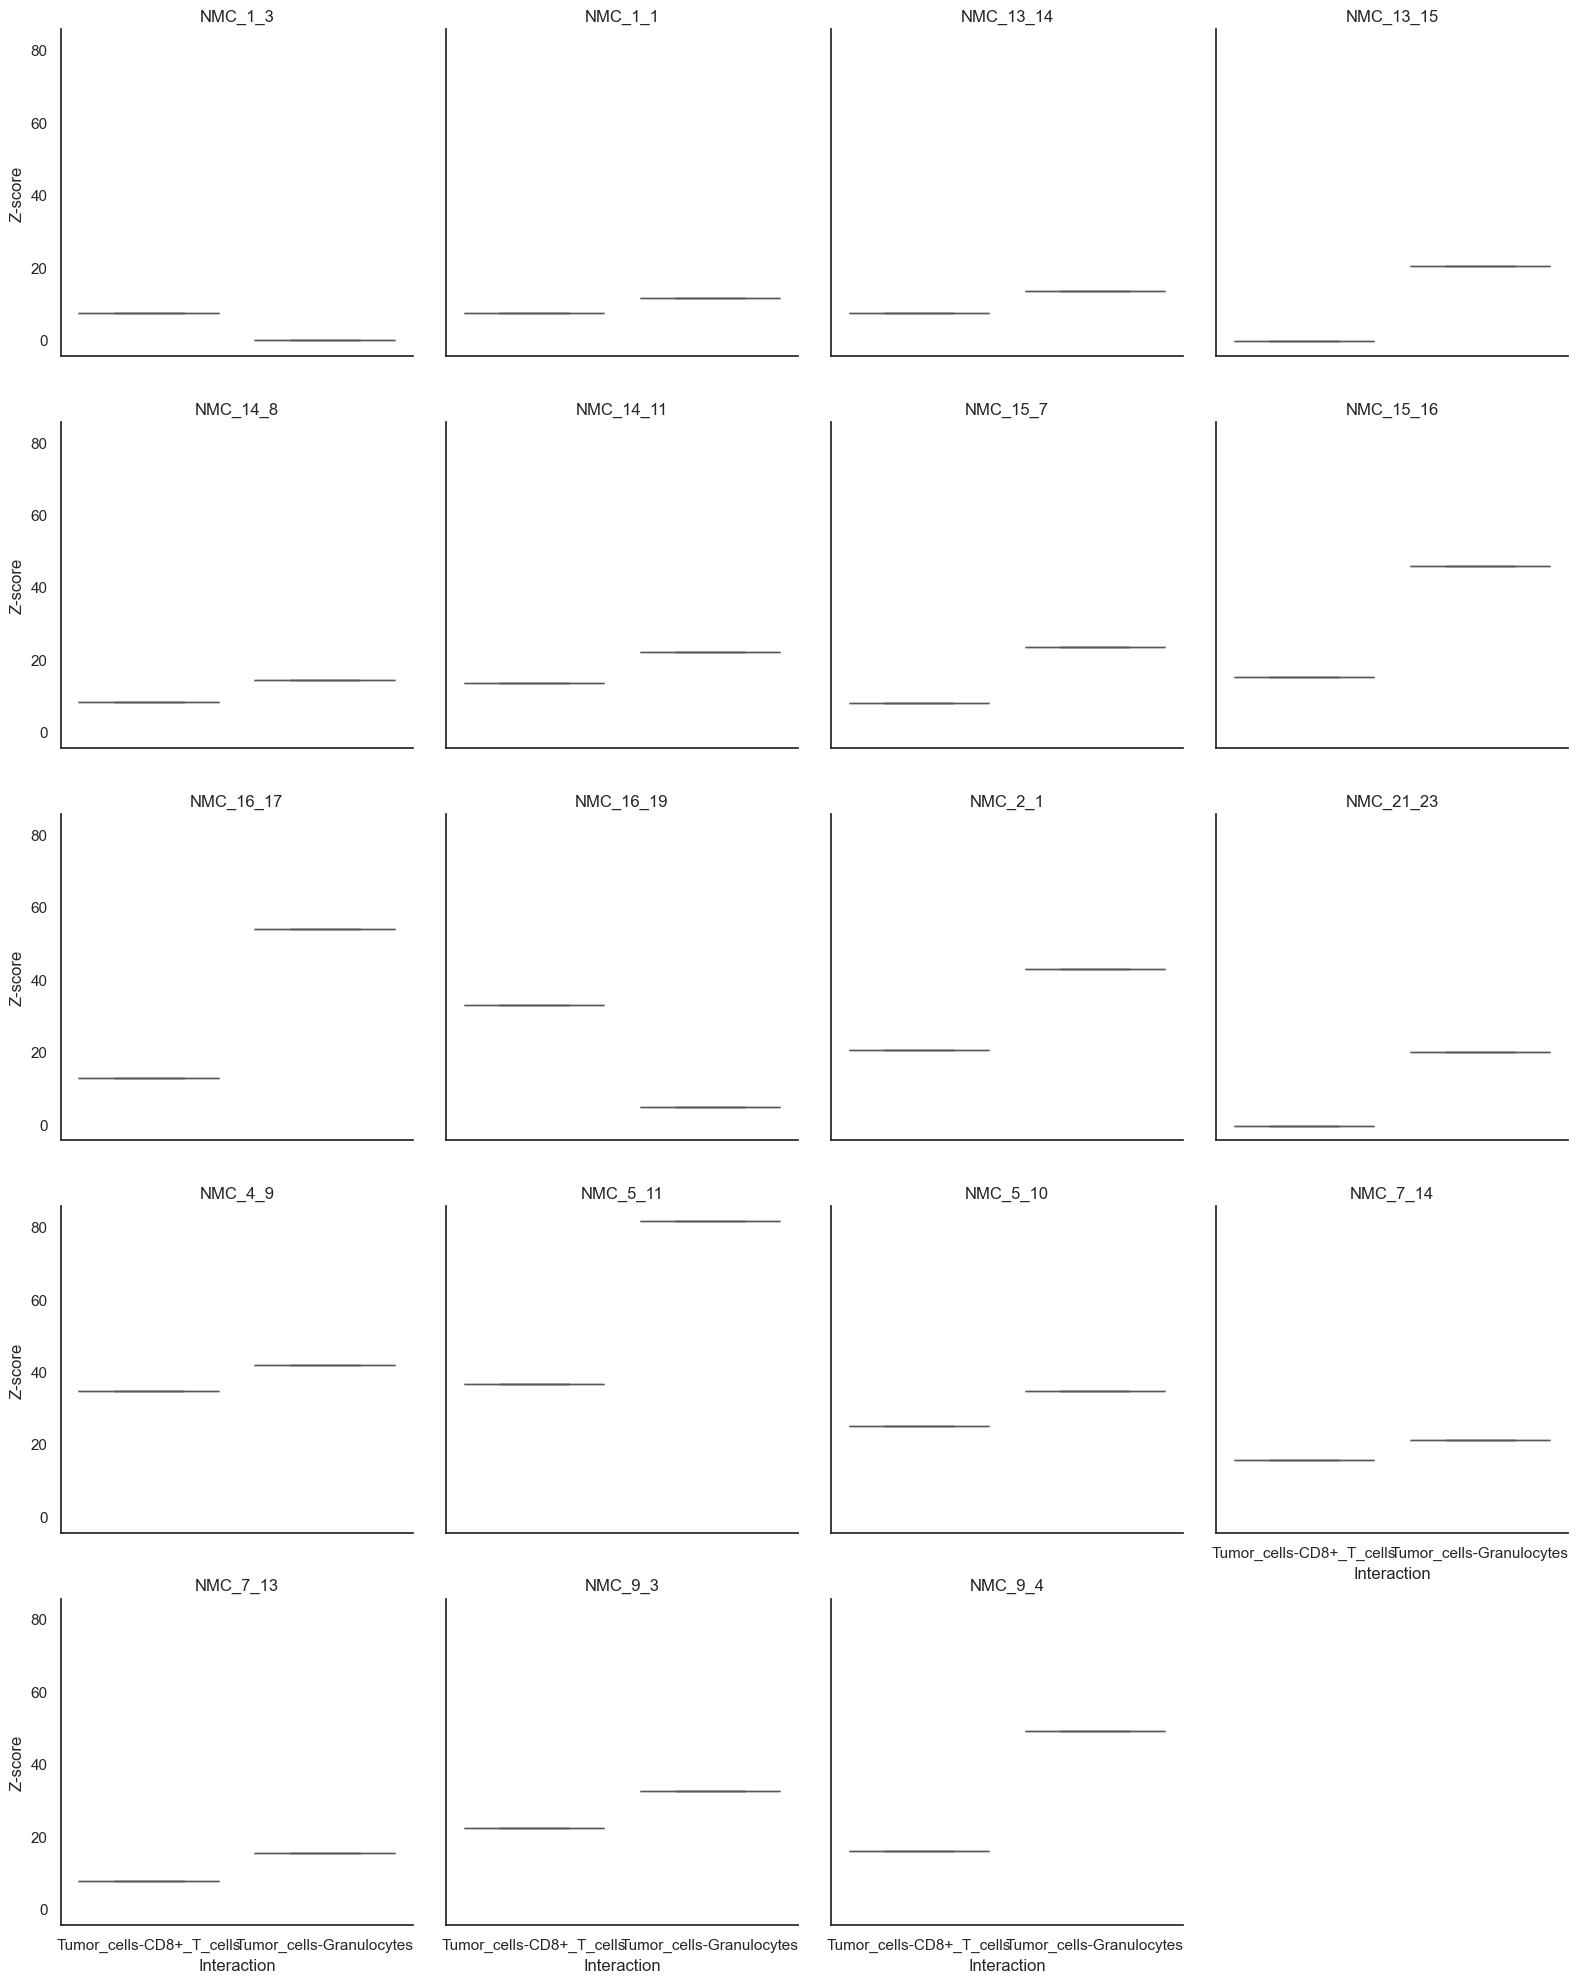

In [52]:
#plot the boxplot of 
plt.figure(figsize=(15, 7))
#add the jitter to the boxplot
#arrange boxplot in decreasing order
order = boxplot_data_select.groupby("patient_ID")["zscore"].median().sort_values(ascending=False).index
sns.boxplot(x="patient_ID", y="zscore", hue="interaction",data=boxplot_data_select, palette="Set2", order=order)
#calculate the pvalue)
plt.xticks(rotation=90)
plt.title("Tumor_cells Interaction")
sns.swarmplot(x="patient_ID", y="zscore", data=boxplot_data_select, color=".25", hue="interaction", dodge=True, legend=False, size=2, log_scale=True)
plt.xticks(rotation=90)
plt.title("Interaction score of Tumor cells with Granulocytes and CD8+ T cells in All Samples")
plt.ylabel("Z-score")
plt.xlabel("Patient ID")
g = sns.catplot(
    x="interaction", y="zscore", col="patient_ID",
    data=boxplot_data_select,
    kind="box",
    col_wrap=4,  # adjust to fit screen
    height=4,
    aspect=1,
    palette="Set2"
)
g.set_titles("{col_name}")
g.set_axis_labels("Interaction", "Z-score")


In [42]:
#replace NA with 0 in the heatmap data
heatmap_data = heatmap_data.fillna(0)
#replace -Inf and +Inf with 0
heatmap_data = heatmap_data.replace(-np.inf, 0)
heatmap_data = heatmap_data.replace(np.inf, 0)

<Figure size 1000x1000 with 0 Axes>

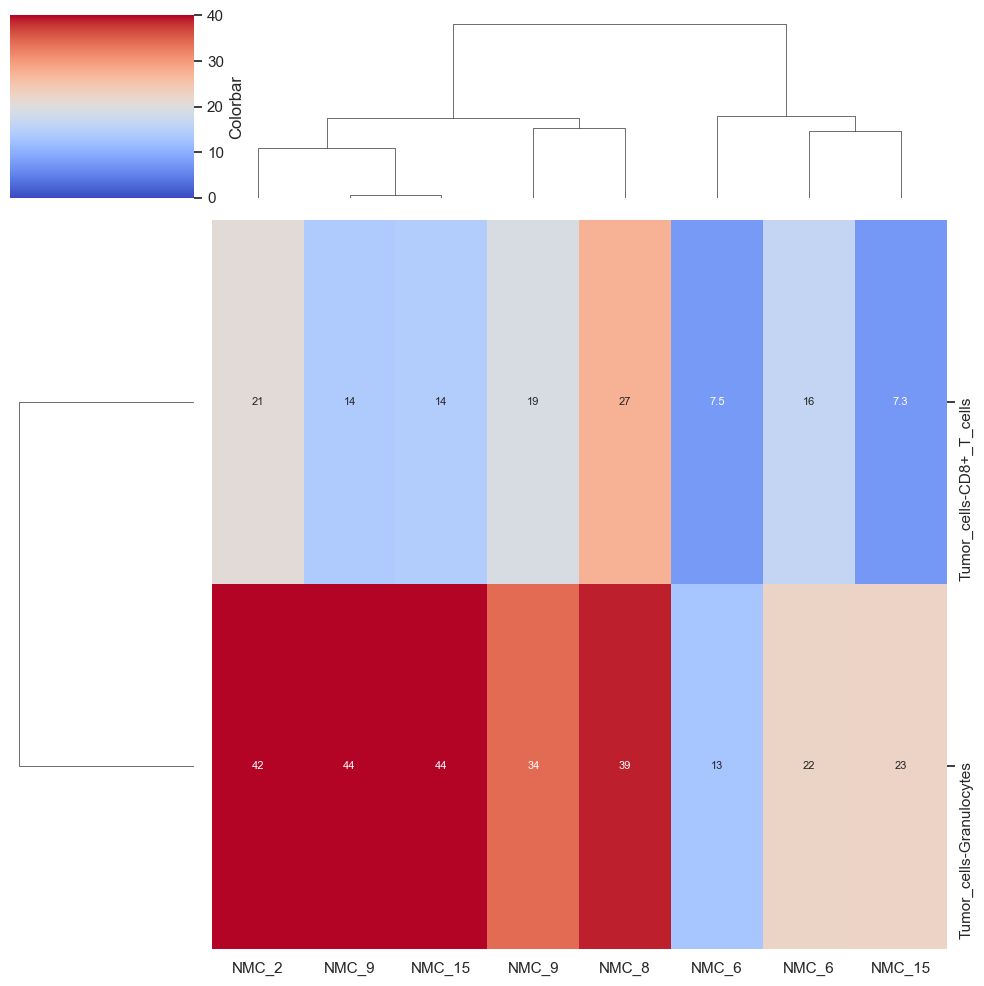

In [84]:
plt.figure(figsize=(10, 10))

# Plot the heatmap
#ADJUST THE SCALE OF THE HEATMAP
# Use a diverging colormap for better visualization
# Create a custom diverging colormap
# Create the clustermap
sns.clustermap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Colorbar'},  # Optional, for better colorbar label
    vmin=0,
    vmax=40
)

# Rotate row labels for better readability
plt.yticks(rotation=0)  # You can adjust this angle as needed (0 for horizontal)

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

PosixPath('/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed')

In [24]:
adata.obs.loc[:, ["outcome_group", "exp_name", "site"]].drop_duplicates()

,outcome_group,exp_name,site
0,long_term survival,Run141_ROI11,extrahepatic bile ducts
0-1,short_term survival,Run141_ROI16,lung
0-2,short_term survival,Run141_ROI7,lung
0-3,long_term survival,Run141_ROI19,"cervical, A. carotis int. right"
0-4,short_term survival,Run141_ROI1,lung hilus right
0-5,long_term survival,Run141_ROI8,extrahepatic bile ducts
0-6,long_term survival,Run141_ROI17,"cervical, A. carotis int. right"
0-7,short_term survival,Run141_ROI15,"sample: metastasis left tigh, skin \nprimary s..."
0-8,short_term survival,Run141_ROI4,central left lung
0-9,short_term survival,Run141_ROI23,"intrathoracic, right bronchus"


In [12]:
cell_colors = {
    "Tumor_cells": "#FF6347",  # Tomato red
    "Actin+_cells": "grey",  # Steel blue
    "CD8+_T_cells": "#32CD32",  # Lime green
    "M1_macrophages": "#FFD700",  # Gold
    "Treg_T_cells": "#8A2BE2",  # Blue violet
    "M2_macrophages": "#00FA9A",  # Medium spring green
    "DCs": "#FF4500",  # Orange red
    "Endothelial_cells": "#2E8B57",  # Sea green
    "CD4+_T_cells": "#9932CC",  # Dark orchid
    "Mast_cells": "#DAA520",  # Goldenrod
    "Lymphatic_endothelial_cells": "#A52A2A",  # Brown
    "Granulocytes": "#C71585",  # Medium violet red
    "M1_M2_macrophages": "#D2691E",  # Chocolate
    "Plasma_cells": "#8B0000",  # Dark red
    "B_cells": "#4169E1",  # Royal blue
    "MDSCs": "#B22222",  # Firebrick
    "Epithelial_cells": "#228B22",  # Forest green
    "NK_cells": "#FF1493"  # Deep pink
}

In [119]:
long_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"]]
short_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]


In [121]:
boxplot_data = heatmap_data.melt(var_name='variable', value_name='value', ignore_index=False)
boxplot_data = boxplot_data.filter(like = "CD8+_T_cells-Tumor_cells", axis=0)
boxplot_data["group"] = np.where(boxplot_data["variable"].isin(long_term_zscore), "Long_term", "Short_term")
boxplot_data


,variable,value,group
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI11,-15.521816,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI19,-8.852351,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI8,-28.027726,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI17,-14.573462,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI16,0.350344,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI7,1.055972,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI15,1.813534,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI23,1.628872,Short_term


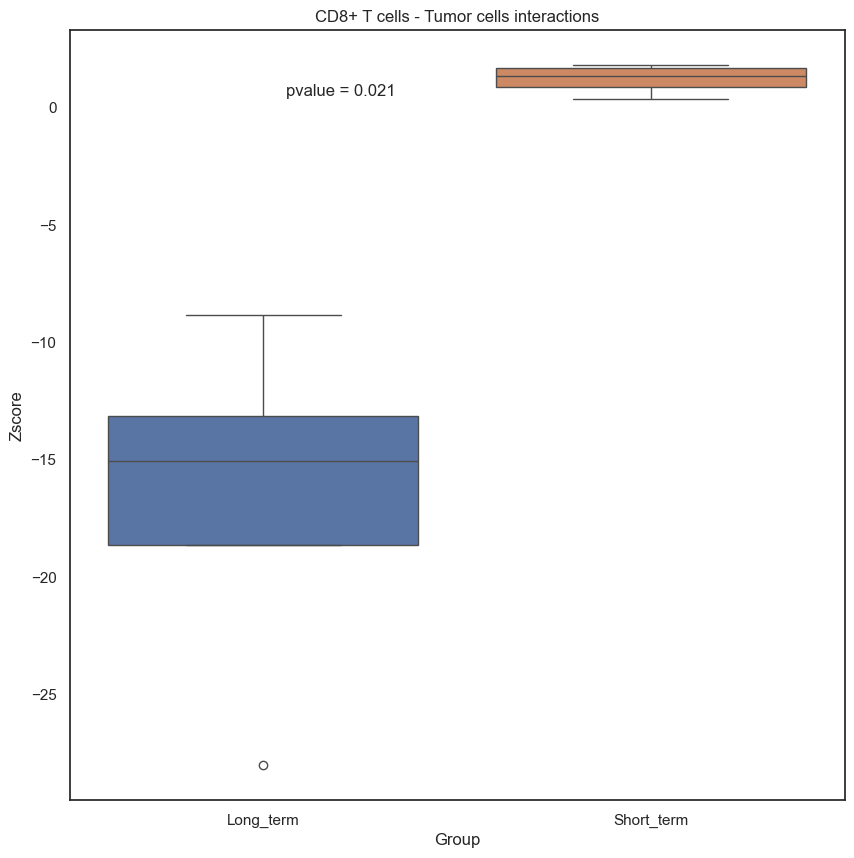

In [136]:
#build a boxplot based on boxplt_data based on matplot
#add the jitter to the boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x='group', y='value', hue='group', data=boxplot_data)
#add title to box plot and labels
plt.title('CD8+ T cells - Tumor cells interactions')
plt.xlabel('Group')
plt.ylabel('Zscore')
#calculate pvalue based on wilcox and add it to the plot
pvalue = sp.stats.ranksums(boxplot_data[boxplot_data["group"] == "Long_term"]["value"], boxplot_data[boxplot_data["group"] == "Short_term"]["value"]).pvalue.round(3)
plt.text(0.2, 0.5, "pvalue = " + str(pvalue), fontsize=12, ha='center')
plt.show()

In [147]:
adata_long = adata[adata.obs["exp_name"].isin(["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"])]
adata_short = adata[adata.obs["exp_name"].isin(["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"])]

In [153]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


In [33]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                         phenotype='cell_type', label='2D_distance', imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run145_ROI3
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run145_ROI10
Processing Image: Run145_ROI17
Processing Image: Run145_ROI11
Processing Image: Run103_ROI5
Processing Image: Run141_ROI15
Processing Image: Run145_ROI1
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run145_ROI9
Processing Image: Run141_ROI14
Processing Image: Run145_ROI14
Processing Image: Run145_ROI13
Processing Image: Run103_ROI6


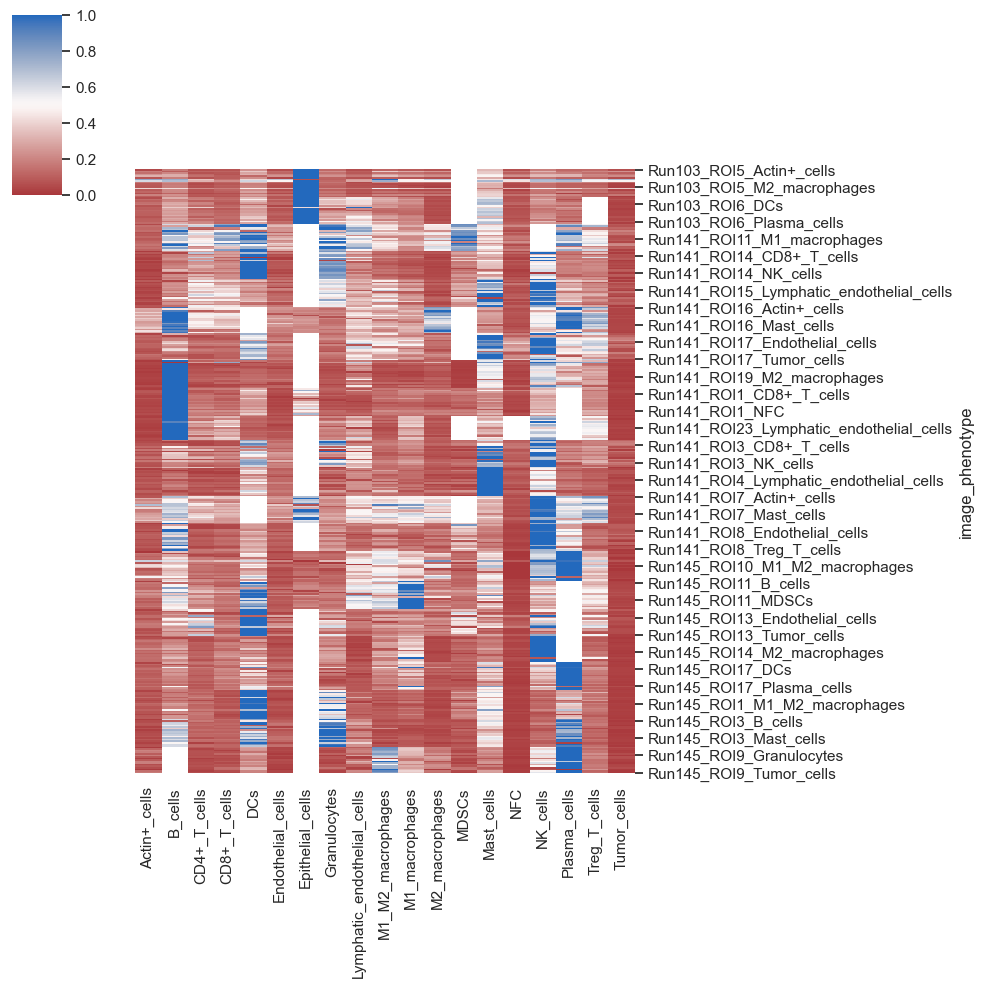

In [37]:
sm.pl.spatial_distance(adata, phenotype="cell_type", imageid="exp_name", spatial_distance='2D_distance', heatmap_summarize=False)

In [1]:
sm.pl.spatial_distance(adata_long, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')
sm.pl.spatial_distance(adata_short, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')


NameError: name 'sm' is not defined

In [9]:
#Proportion of Granulocytes to CD4+
proportion = adata.obs.groupby(["patient_ID", "cell_type"]).size().unstack().fillna(0)[["Granulocytes", "CD4+_T_cells", "CD8+_T_cells"]]
#calculate total number of cells
proportion["total"] = proportion.sum(axis=1)
proportion["T_cells"] = proportion["CD4+_T_cells"] + proportion["CD8+_T_cells"]
#calculate the proportion of Granulocytes to T_cells
proportion["Granulocytes_to_T_cells"] = proportion["Granulocytes"] / proportion["T_cells"]
#normalize it by the total number of cells
proportion["Granulocytes_to_T_cells"] = (proportion["Granulocytes_to_T_cells"] / proportion["total"]) * 1000
proportion = proportion.reset_index()
#stabalizze it
proportion["Granulocytes_to_T_cells"] = np.log1p(proportion["Granulocytes_to_T_cells"])
proportion

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_12917/183556760.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



cell_type,patient_ID,Granulocytes,CD4+_T_cells,CD8+_T_cells,total,T_cells,Granulocytes_to_T_cells
0,NMC_1,6,131,226,363,357,0.045260
1,NMC_2,704,155,176,1035,331,1.116768
2,NMC_4,1230,416,515,2161,931,0.477082
3,NMC_5,3183,1169,1472,5824,2641,0.188089
4,NMC_6,1737,1194,1877,4808,3071,0.111219
5,NMC_7,184,541,447,1172,988,0.147474
6,NMC_8,3008,182,144,3334,326,1.326424
7,NMC_9,5415,9492,8187,23094,17679,0.013176
8,NMC_13,9,28,25,62,53,1.318789
9,NMC_14,138,1623,596,2357,2219,0.026043


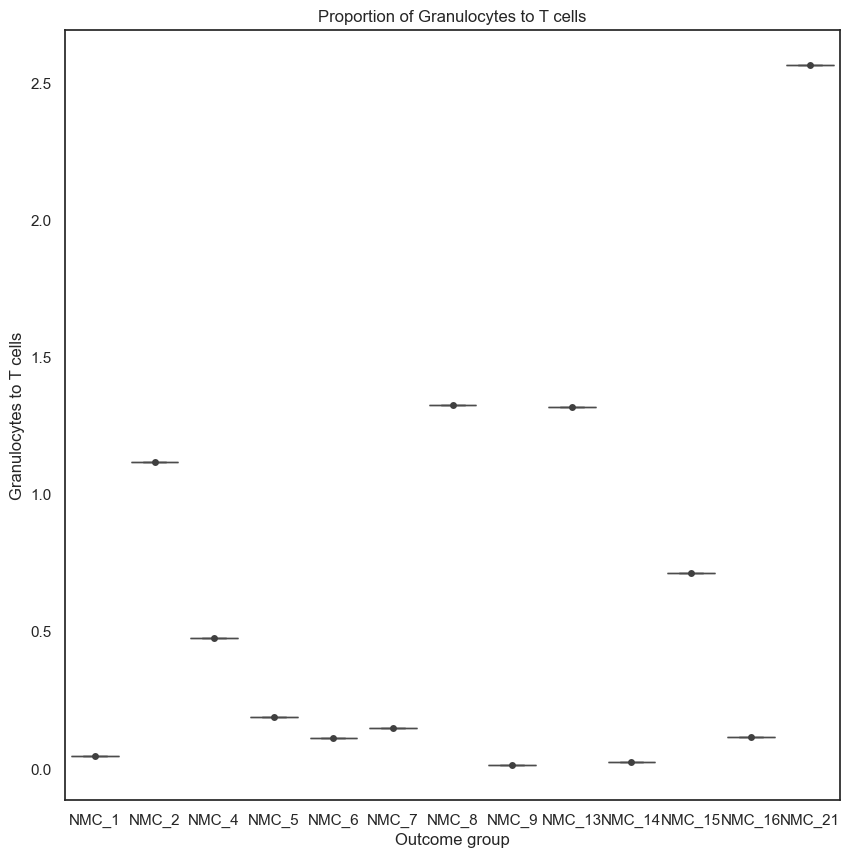

In [10]:
#plotting boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion)
sns.swarmplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion, color=".25", dodge=True, legend=False, size=5)
plt.title("Proportion of Granulocytes to T cells")
plt.ylabel("Granulocytes to T cells")
plt.xlabel("Outcome group")
plt.show()

array([[ 3.364911  , -0.05504028,  1.4204489 , ..., -0.625759  ,
         0.6410527 ,  0.8886294 ],
       [ 0.24970348, -1.0339532 ,  1.7215923 , ...,  0.3054985 ,
         0.22106291,  0.9939115 ],
       [ 1.27325   , -1.2512585 ,  2.1407115 , ...,  0.30332476,
         0.21192957,  0.66310835],
       ...,
       [-0.99729556, -0.4536652 , -1.1325684 , ...,  0.93053603,
         0.14767537,  1.3336124 ],
       [-1.2233319 , -0.45298016, -1.4159251 , ...,  1.2389164 ,
         0.16221976,  1.4863019 ],
       [-1.1030433 , -0.42845234, -1.2105902 , ...,  0.426439  ,
        -0.08300974,  0.6062372 ]], dtype=float32)

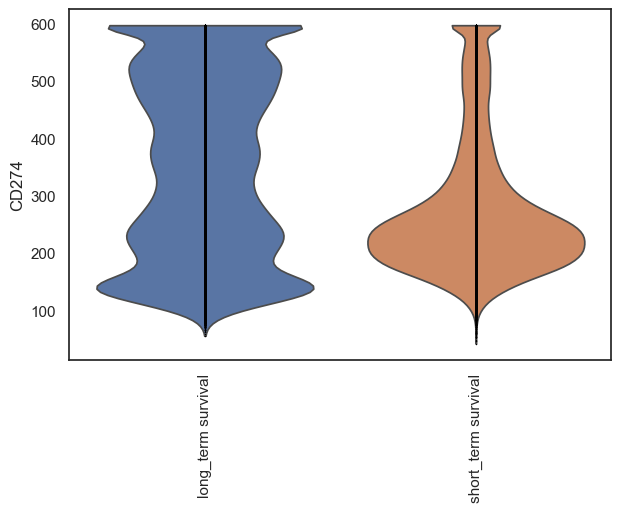

In [63]:
sc.pl.violin(adata, keys="CD274", groupby='outcome_group', jitter=0.001, rotation=90, size=1)
#Calculate pvalues

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_2346/1166554079.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



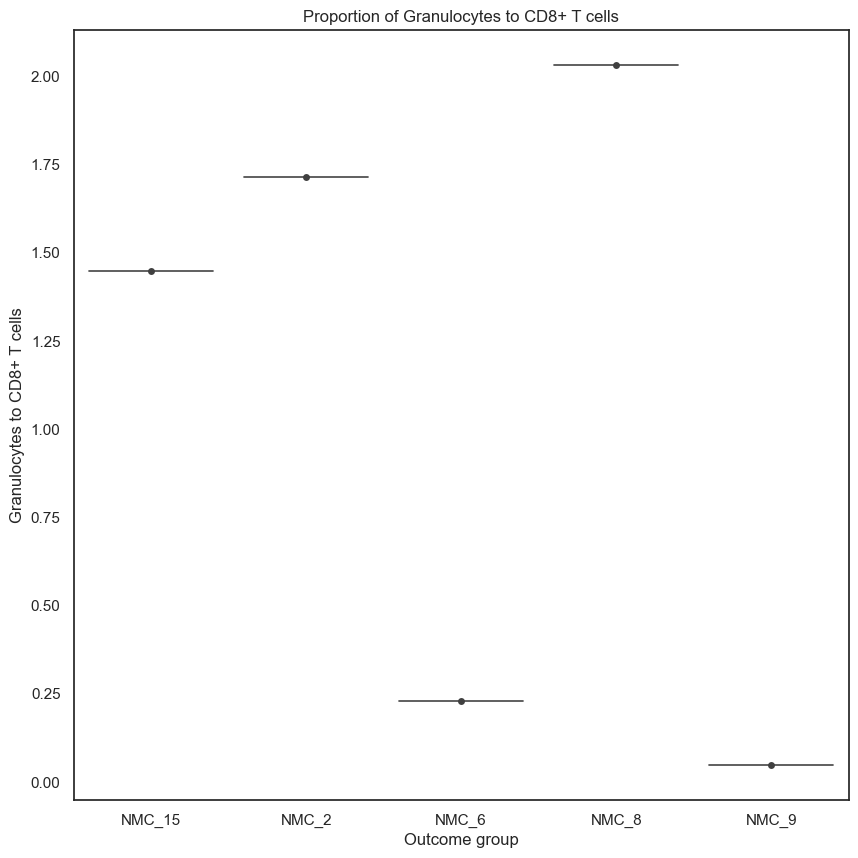

In [87]:
#ratio of Granulocytes to CD8+ T cells in adata_lung
proportion = adata_lung.obs.groupby(["patient_ID", "cell_type"]).size().unstack().fillna(0)[["Granulocytes", "CD8+_T_cells"]]
#calculate total number of cells
proportion["total"] = proportion.sum(axis=1)
proportion["T_cells"] = proportion["CD8+_T_cells"]
#calculate the proportion of Granulocytes to T_cells
proportion["Granulocytes_to_T_cells"] = proportion["Granulocytes"] / proportion["T_cells"]
#normalize it by the total number of cells
proportion["Granulocytes_to_T_cells"] = (proportion["Granulocytes_to_T_cells"] / proportion["total"]) * 1000
proportion = proportion.reset_index()
#stabalizze it
proportion["Granulocytes_to_T_cells"] = np.log1p(proportion["Granulocytes_to_T_cells"])
proportion
#plotting boxplot
plt.figure(figsize=(10, 10))
sns.violinplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion)
sns.swarmplot(x="patient_ID", y="Granulocytes_to_T_cells", data=proportion, color=".25", dodge=True, legend=False, size=5)
plt.title("Proportion of Granulocytes to CD8+ T cells")
plt.ylabel("Granulocytes to CD8+ T cells")
plt.xlabel("Outcome group")
plt.show()


In [10]:
for i in adata.obs.cell_type.unique():
    print(i)

NFC
Tumor_cells
Actin+_cells
CD8+_T_cells
M1_macrophages
Treg_T_cells
M2_macrophages
DCs
Endothelial_cells
CD4+_T_cells
Mast_cells
Lymphatic_endothelial_cells
Granulocytes
M1_M2_macrophages
Plasma_cells
B_cells
MDSCs
Epithelial_cells
NK_cells


In [12]:
#create a column with T cells grouped, Macrophages grouped, and Granulocytes and MDScs
adata.obs["cell_type_group"] = adata.obs["cell_type"].replace({
    "CD4+_T_cells": "T cells",
    "CD8+_T_cells": "T cells",
    "Treg_T_cells": "T cells",
    "NK_cells": "T cells",
    "M1_macrophages": "Macrophages",
    "M2_macrophages": "Macrophages",
    "M1_M2_macrophages": "Macrophages",
    "MDSCs": "Granulocytes and MDSCs",
    "Granulocytes": "Granulocytes and MDSCs",
    "Plasma_cells": "B cells",
    "B_cells": "B cells"
})

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/588520696.py:2: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/529893712.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1000x1000 with 0 Axes>

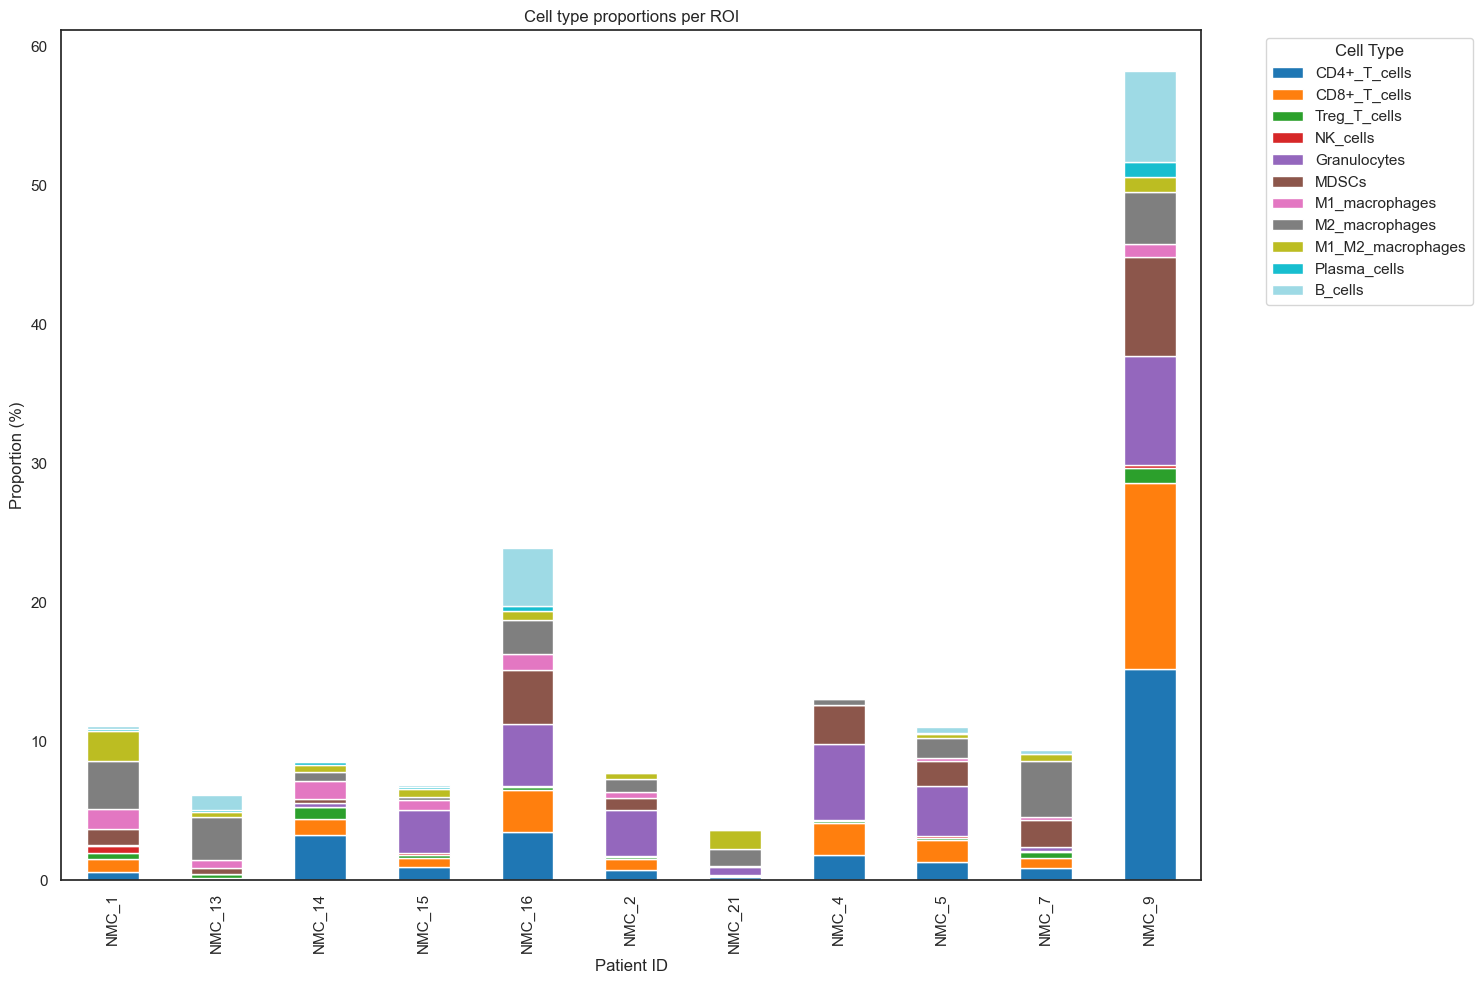

In [11]:
#calculate cell type proportions per ROI
counts_exp = adata.obs.groupby(["patient_ID", "cell_type"]).size().unstack()
counts_exp = counts_exp.div(counts_exp.sum(axis=1), axis=0).mul(100).round(2)
#select CD4+_T_cells, CD8+_T_cells, Granulocytes, Tumor_cells, MDSCs
counts_exp = counts_exp[["CD4+_T_cells", "CD8+_T_cells", "Treg_T_cells", "NK_cells", "Granulocytes", "MDSCs", "M1_macrophages", "M2_macrophages", "M1_M2_macrophages", "Plasma_cells", "B_cells"]]
#plot it as a stacked bar plot
plt.figure(figsize=(10, 10))
counts_exp.plot(kind='bar', stacked=True, colormap="tab20", figsize=(15, 10))
plt.title("Cell type proportions per ROI")
plt.xlabel("Patient ID")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=90)
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_5766/3743139126.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1000x1000 with 0 Axes>

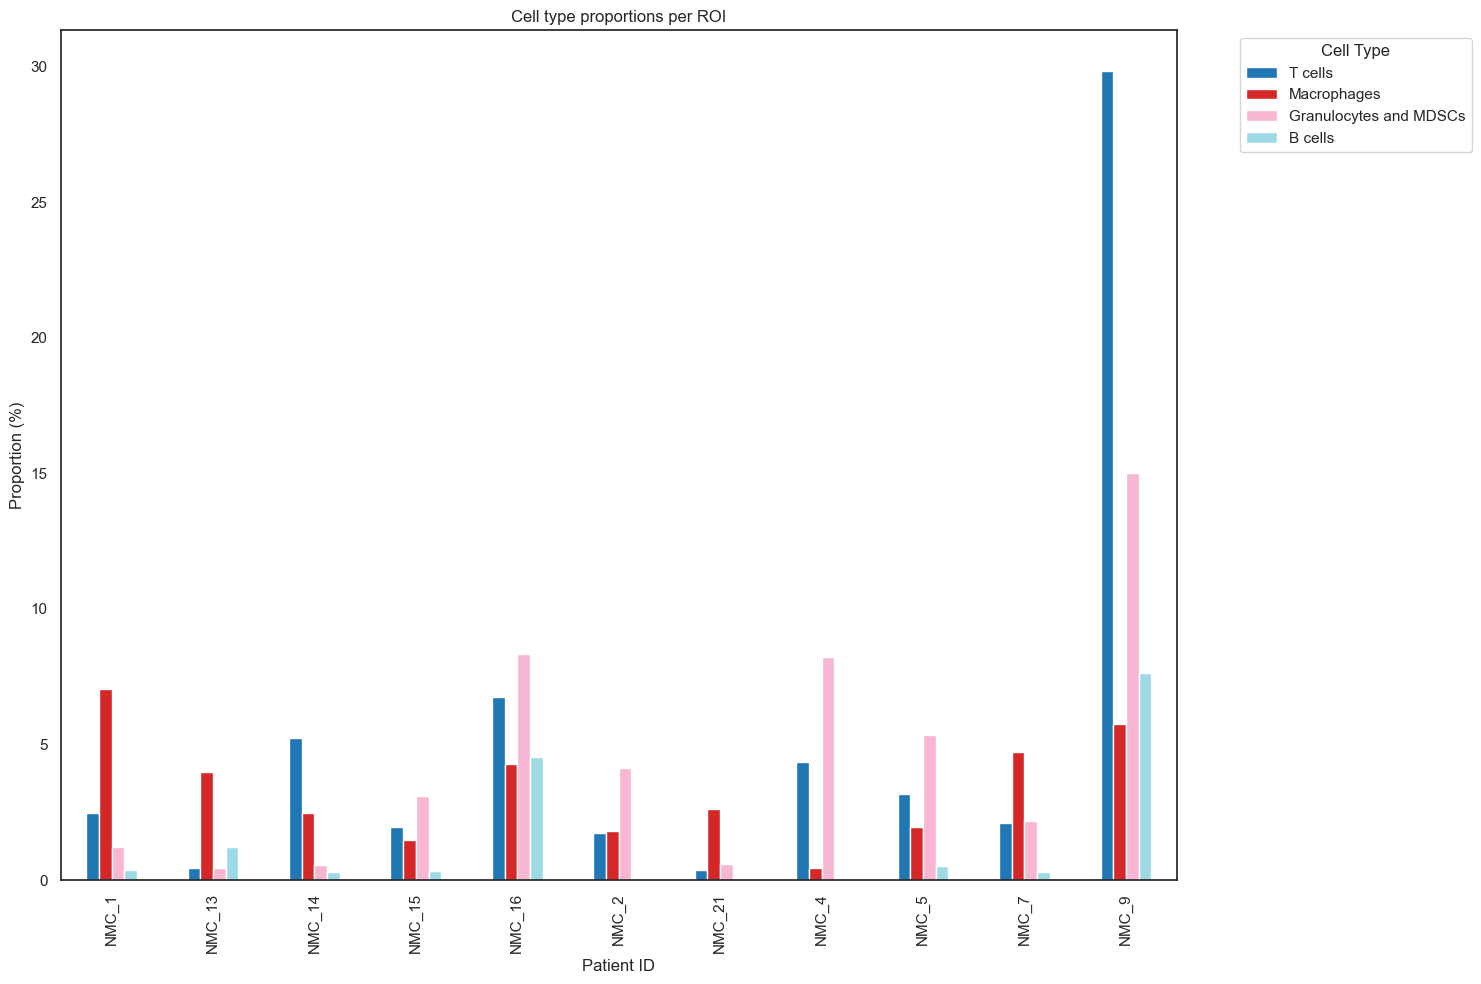

In [16]:
#calculate cell type proportions per ROI
counts_exp = adata.obs.groupby(["patient_ID", "cell_type_group"]).size().unstack()
counts_exp = counts_exp.div(counts_exp.sum(axis=1), axis=0).mul(100).round(2)
#select CD4+_T_cells, CD8+_T_cells, Granulocytes, Tumor_cells, MDSCs
counts_exp = counts_exp[["T cells", "Macrophages", "Granulocytes and MDSCs", "B cells"]]
#plot it as a stacked bar plot
plt.figure(figsize=(10, 10))
counts_exp.plot(kind='bar', stacked=False, colormap="tab20", figsize=(15, 10))
plt.title("Cell type proportions per ROI")
plt.xlabel("Patient ID")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=90)
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()